## Trying to find methods to determine convergence

In [1]:
%load_ext memory_profiler
import os, gc
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
import pickle
import matplotlib.pyplot as plt
import numpy as np
from memory_profiler import memory_usage
import sys
sys.path.append('/home/anas/Desktop/Simulations/Training_NLO/nonlinear_oscillator_network/Utils')

from NN_utils import *
from kneed import KneeLocator
import scipy
#from torchvision import datasets, transforms
#from torchsummary import summary
import time
from optimization_algorithms import * 

In [2]:
def convergence_relative_improvement(loss_curve, threshold=1e-3, window=10):
    """
    Stop when relative improvement over 'window' steps is below 'threshold'.
    """
    for t in range(window, len(loss_curve)):
        rel_improvement = abs(loss_curve[t] - loss_curve[t-window]) / max(loss_curve[t-window], 1e-12)
        if rel_improvement < threshold:
            return t
    return len(loss_curve) - 1

def convergence_slope_loglog(loss_curve, threshold=1e-2, window=10):
    """
    Stop when slope on log-log curve over 'window' steps is below 'threshold'.
    """
    epochs = np.arange(1, len(loss_curve) + 1)  # avoid log(0)
    for t in range(window, len(loss_curve)):
        x = np.log(epochs[t-window:t+1])
        y = np.log(loss_curve[t-window:t+1] + 1e-12)
        slope, _ = np.polyfit(x, y, 1)  # linear fit
        if abs(slope) < threshold:
            return t
    return len(loss_curve) - 1

def convergence_relative_slope_loglog(loss_curve, fraction=0.01, window=10, eps=1e-12):
    """
    Converges when the local |slope| in log-log space falls below
    `fraction * max_abs_slope` (computed over all windows).
    """
    N = len(loss_curve)
    if N < max(3, window):
        return N - 1  # not enough data for a reliable slope

    epochs = np.arange(1, N + 1)  # avoid log(0)
    x_full = np.log(epochs)
    y_full = np.log(loss_curve + eps)

    # Compute local slopes via linear fit within each window (inclusive)
    slopes = []
    centers = []  # index to map each slope to an epoch (use right edge for consistency)
    for t in range(window - 1, N):
        x = x_full[t - (window - 1): t + 1]
        y = y_full[t - (window - 1): t + 1]
        slope, _ = np.polyfit(x, y, 1)
        slopes.append(slope)
        centers.append(t)  # right edge of the window

    slopes = np.array(slopes)
    centers = np.array(centers)

    max_abs_slope = np.max(np.abs(slopes))
    # If the curve is already flat (degenerate case)
    if max_abs_slope <= 0:
        return N - 1

    threshold = fraction * max_abs_slope

    # First epoch where local |slope| is small w.r.t. the max
    mask = np.abs(slopes) <= threshold
    if np.any(mask):
        return int(centers[np.argmax(mask)])  # first True
    else:
        return N - 1

def knee_point_loglog(loss_curve):
    """
    Find knee (elbow) of loss curve in log-log space using curvature.

    """
    epochs = np.arange(1, len(loss_curve) + 1)
    x = np.log(epochs)
    y = np.log(loss_curve + 1e-12)

    # first and second derivatives (finite differences)
    dy = np.gradient(y, x)
    d2y = np.gradient(dy, x)

    curvature = np.abs(d2y) / (1 + dy**2) ** 1.5
    knee_idx = np.argmax(curvature)
    return knee_idx

In [5]:
N_neurons_vec = [5, 10, 20 ,30, 50, 75, 100]

with open('paramscan_l2regularization_PNN_PEPG_MNIST.pkl', 'rb') as f:
    results1 = pickle.load(f)

with open('paramscan_l2regularization_PNN_PEPG_MNIST_run2.pkl', 'rb') as f:
    results2 = pickle.load(f)

with open('paramscan_l2regularization_PNN_PEPG_MNIST_run3.pkl', 'rb') as f:
    results3 = pickle.load(f)

dicts_list = [results1, results2,results3]  # list of runs

# Average them
avg_results = []
for i in range(len(N_neurons_vec)):          # loop over neuron settings
    avg_dict = {}
    keys = dicts_list[0][i].keys()           # e.g. 'train_loss', 'test_loss'
    for key in keys:
        stacked = np.stack([d[i][key] for d in dicts_list])  # shape: (n_runs, vec_len)
        avg_dict[key] = stacked.mean(axis=0)
    avg_results.append(avg_dict)

dict_keys(['train_loss', 'test_loss', 'test_acc', 'time', 'n_params'])

In [4]:
test_loss_mat = np.zeros((len(N_neurons_vec),len(avg_results[0]['test_loss'])))
train_loss_mat = np.zeros((len(N_neurons_vec),len(avg_results[0]['train_loss'])))

for k,D in enumerate(avg_results):

    test_loss_mat[k,:] = D['test_loss']
    train_loss_mat[k,:] = D['train_loss']




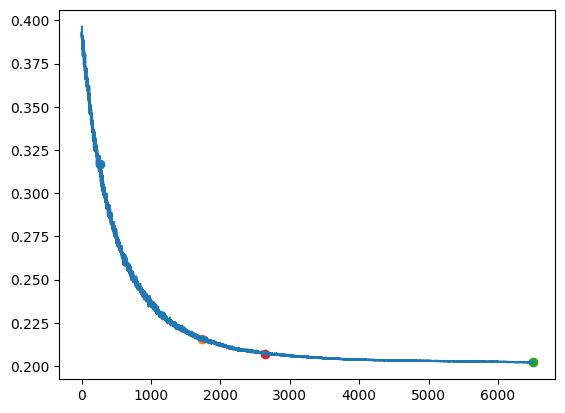

In [5]:
idx_curve =-1
idx_start = 500
idx_end = -1
loss_vec = test_loss_mat[idx_curve,idx_start:idx_end]
e_conv1 = convergence_relative_improvement(loss_vec, threshold=5e-3, window=50)
e_conv2 = convergence_slope_loglog(loss_vec, threshold=1e-2, window=50)
e_conv3 = convergence_relative_slope_loglog(loss_vec, fraction=1-2, window=50)
e_conv4 = knee_point_loglog(loss_vec)

plt.plot(loss_vec)
plt.scatter(e_conv1,loss_vec[e_conv1])
plt.scatter(e_conv2,loss_vec[e_conv2])
plt.scatter(e_conv3,loss_vec[e_conv3])
plt.scatter(e_conv4,loss_vec[e_conv4])


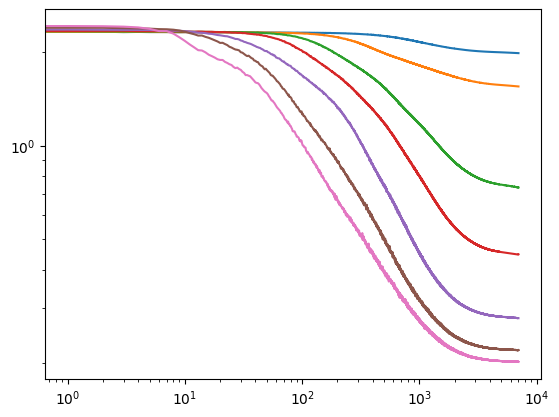

In [6]:
plt.loglog(test_loss_mat.T)

### Knee method below works quite well and is consistent
- it measures the distance from the normalized loss curve to a diagonal knee is reached when distance is max

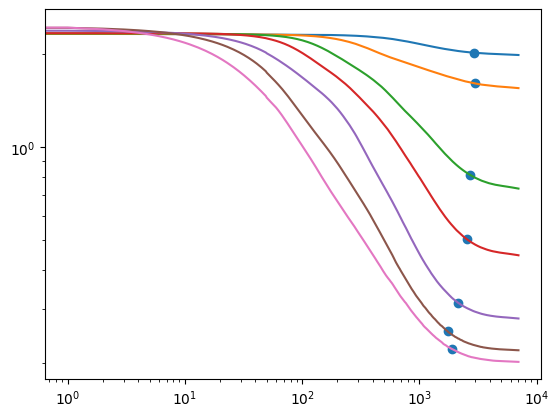

In [ ]:

test_loss_smooth = scipy.signal.savgol_filter(test_loss_mat,window_length=100,polyorder=3,axis=-1)
knee_idx = []
for k in range(len(N_neurons_vec)):
    kneedle = KneeLocator(
        np.arange(idx_start,np.shape(test_loss_smooth)[-1]), test_loss_smooth[k,idx_start:7000+1],
        S=1.0,                     # sensitivity (larger -> fewer knees)
        curve="convex",            # try "concave" if your curve bends the other way
        direction="decreasing",    # loss goes down with epochs
        online=False
    )

    knee_idx.append(int(kneedle.knee + idx_start)) 


plt.loglog(test_loss_smooth.T)
plt.scatter(knee_idx,test_loss_smooth[np.arange(len(N_neurons_vec)),knee_idx])

In [57]:

idx_conv=[]

for k,n in enumerate(N_neurons_vec):

    loss_vec = test_loss_smooth[k,idx_start:idx_end]
    idx_conv.append(knee_point_loglog(loss_vec) + idx_start)

idx_conv = np.array(idx_conv)

    

In [58]:
print(idx_conv)
print(knee_idx)

[6719 6868 6851 2627 6945 2577 6745]
[2898, 2970, 2720, 2540, 2141, 1745, 1891]


In [9]:
#memory cost computation 
def peak_mem_increment(func, *args, interval=0.05, **kwargs):
    # Track process memory over time while func runs; return (peak - baseline) MiB
    baseline = memory_usage(max_iterations=1)[0]
    mem_series = memory_usage((func, args, kwargs), interval=interval)
    return max(mem_series) - baseline

mem_cost_pepg = []
N_dim_vec=[]
for k,n in enumerate(N_neurons_vec):
    X = []
    N_dim = int(avg_results[k]['n_params'])
    N_dim_vec.append(N_dim)
    pop_size = int((0.01*N_dim))
    pop_size = pop_size + 1 if pop_size % 2 else pop_size

    coordinates = np.random.randn(pop_size,N_dim)
    init_pos = np.random.randn(N_dim,1)
    rewards = np.random.randn(pop_size,1)

    PEPG_optimizer = PEPG_opt(N_dim, pop_size = pop_size, learning_rate=0.01, starting_mu=init_pos ,starting_sigma=1e-1)
    mem_load2 = peak_mem_increment(PEPG_optimizer.ask, interval=0.05)

    mem_load1 = peak_mem_increment(PEPG_optimizer.tell, rewards, interval=0.05)

    mem_cost_pepg.append(mem_load1 + mem_load2)

    del PEPG_optimizer

mem_cost_pepg = np.array(mem_cost_pepg) * 1048576/1e6




slope 1.7545332401038503
intercept -2.0709813739577707


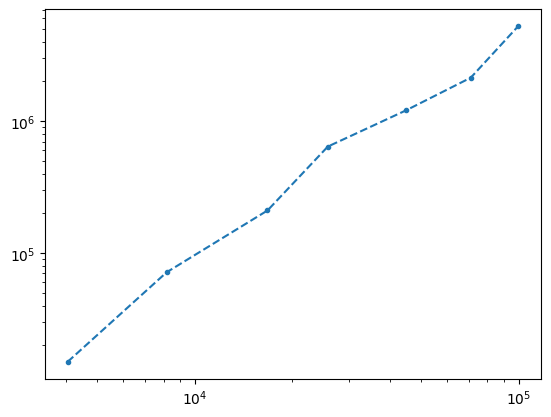

In [59]:
cost_to_conv = mem_cost_pepg * knee_idx
plt.loglog(N_dim_vec,cost_to_conv,'--.')
a, b = np.polyfit(np.log10(N_dim_vec), np.log10(cost_to_conv), 1)  # linear fit
print(f'slope {a}')
print(f'intercept {b}')

In [22]:
print(cost_to_conv)
print(N_dim_vec)

[   30199.64416    163696.80384    653115.322368  1563341.45536
  3798599.159808  8749873.025024 18248579.56352 ]
[4045, 8180, 16750, 25720, 44860, 71035, 99710]


In [3]:
N_neurons_vec = [5, 10, 20 ,30, 50, 75, 100]

with open('paramscan_PNN_SPSA_l2reg_MNIST.pkl', 'rb') as f:
    results_SPSA1 = pickle.load(f)

with open('paramscan_PNN_SPSA_l2reg_MNIST_run2.pkl', 'rb') as f:
    results_SPSA2 = pickle.load(f)

with open('paramscan_PNN_SPSA_l2reg_MNIST_run4.pkl', 'rb') as f:
    results_SPSA3 = pickle.load(f)

dicts_list = [results_SPSA1, results_SPSA2,results_SPSA3]  # list of runs

# Average them
avg_results_SPSA = []
for i in range(len(N_neurons_vec)):          # loop over neuron settings
    avg_dict = {}
    keys = dicts_list[0][i].keys()           # e.g. 'train_loss', 'test_loss'
    for key in keys:
        stacked = np.stack([d[i][key] for d in dicts_list])  # shape: (n_runs, vec_len)
        avg_dict[key] = stacked.mean(axis=0)
    avg_results_SPSA.append(avg_dict)

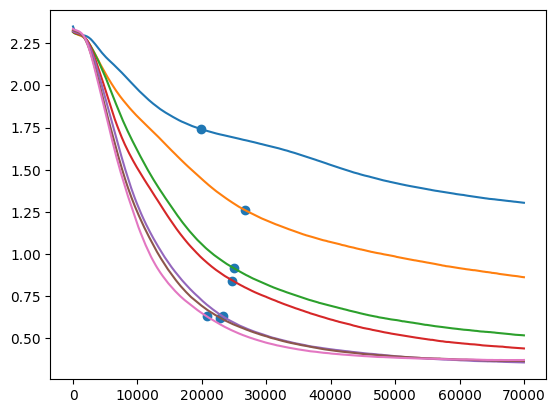

In [4]:

N_neurons_vec = [5, 10, 20 ,30, 50, 75, 100]


test_loss_mat = np.zeros((len(N_neurons_vec),len(avg_results_SPSA[0]['test_loss'])))
train_loss_mat = np.zeros((len(N_neurons_vec),len(avg_results_SPSA[0]['train_loss'])))

for k,D in enumerate(avg_results_SPSA):

    test_loss_mat[k,:] = D['test_loss']
    train_loss_mat[k,:] = D['train_loss']



idx_start = 3000
test_loss_smooth = scipy.signal.savgol_filter(test_loss_mat,window_length=100,polyorder=3,axis=-1)
knee_idx_SPSA = []
for k in range(len(N_neurons_vec)):
    kneedle = KneeLocator(
        np.arange(idx_start,np.shape(test_loss_smooth)[-1]), test_loss_smooth[k,idx_start:len(avg_results_SPSA[0]['test_loss'])+1],
        S=1.0,                     # sensitivity (larger -> fewer knees)
        curve="convex",            # try "concave" if your curve bends the other way
        direction="decreasing",    # loss goes down with epochs
        online=False
    )

    knee_idx_SPSA.append(int(kneedle.knee + idx_start)) 

knee_idx_SPSA = np.array(knee_idx_SPSA)
plt.plot(test_loss_smooth.T)
plt.scatter(knee_idx_SPSA,test_loss_smooth[np.arange(len(N_neurons_vec)),knee_idx_SPSA])

/tmp/ipykernel_14920/1643487890.py:19: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/home/anas/miniconda3/envs/NN_env/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


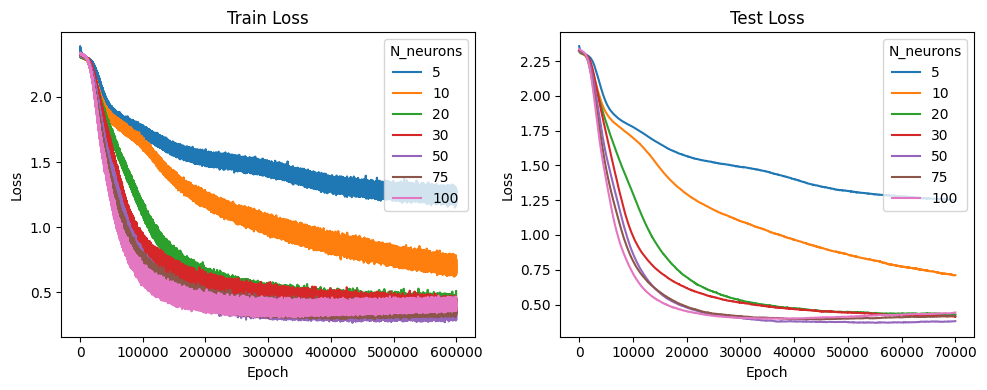

In [66]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

for k, n_neurons in enumerate(N_neurons_vec):
    # Train loss
    axs[0].plot(results_SPSA[k]['train_loss'], label=f"{n_neurons}")
    axs[0].set_title("Train Loss")
    axs[0].set_xlabel("Epoch")
    axs[0].set_ylabel("Loss")

    # Test loss
    axs[1].plot(results_SPSA[k]['test_loss'], label=f"{n_neurons}")
    axs[1].set_title("Test Loss")
    axs[1].set_xlabel("Epoch")
    axs[1].set_ylabel("Loss")

axs[0].legend(title="N_neurons")
axs[1].legend(title="N_neurons")

plt.tight_layout()
plt.show()

In [ ]:
cost_to_conv = mem_cost_spsa * knee_idx_SPSA
plt.loglog(N_dim_vec,cost_to_conv,'--.')
a, b = np.polyfit(np.log10(N_dim_vec), np.log10(cost_to_conv), 1)  # linear fit
print(f'slope {a}')
print(f'intercept {b}')

[4045, 8180, 16750, 25720, 44860, 71035, 99710]
slope 0.7166697988196445
intercept 1.7795178803896563


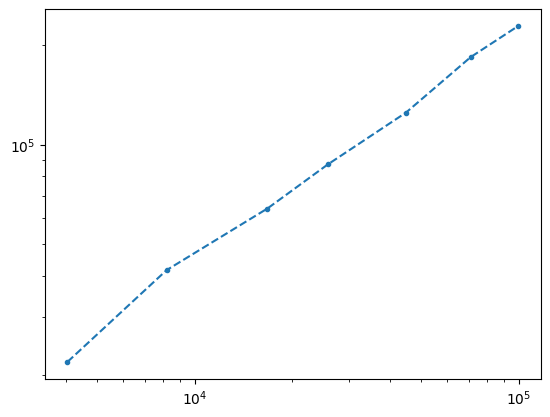

In [7]:
N_dim_vec = []
for k in range(len(avg_results_SPSA)):
    N_dim = int(avg_results_SPSA[k]['n_params'])
    N_dim_vec.append(N_dim)

print(N_dim_vec)
# peak memory data below was measured with the following terminal command  : "scalene --html memory_profile_SPSA.py" only need to change N_dim in the .py script repeatedly
#added tracemalloc memory profiling because scalene does not monitor such a low memory usage per epoch

SPSA_mem_perepoch = [1.102, 1.554,2.559,3.516,5.373,8.092,11.039] # cost in MB 
SPSA_cost_to_conv = SPSA_mem_perepoch * knee_idx_SPSA
plt.loglog(N_dim_vec,SPSA_cost_to_conv,'--.')

a, b = np.polyfit(np.log10(N_dim_vec), np.log10(SPSA_cost_to_conv), 1)  # linear fit
print(f'slope {a}')
print(f'intercept {b}')

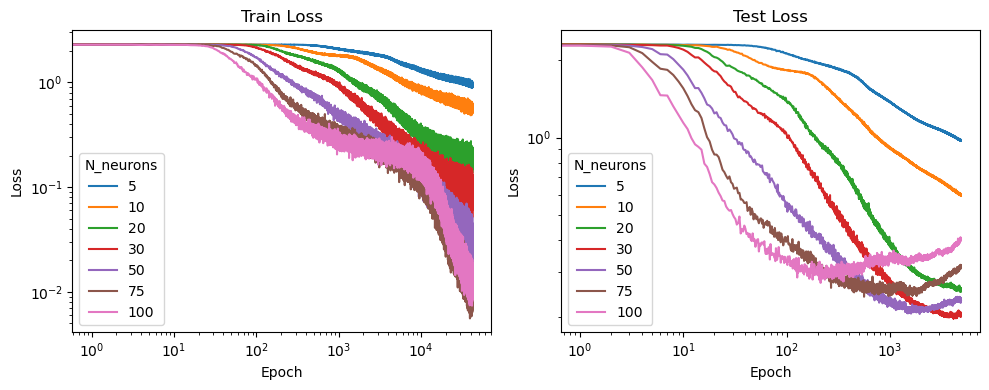

In [52]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

for k, n_neurons in enumerate(N_neurons_vec):
    # Train loss
    axs[0].loglog(results[k]['train_loss'], label=f"{n_neurons}")
    axs[0].set_title("Train Loss")
    axs[0].set_xlabel("Epoch")
    axs[0].set_ylabel("Loss")

    # Test loss
    axs[1].loglog(results[k]['test_loss'], label=f"{n_neurons}")
    axs[1].set_title("Test Loss")
    axs[1].set_xlabel("Epoch")
    axs[1].set_ylabel("Loss")

axs[0].legend(title="N_neurons")
axs[1].legend(title="N_neurons")

plt.tight_layout()
plt.show()
